# Stage 2 — activation, one dataset per cohort

Parcel timeseries: one row per TR, one float32 column per parcel, four cohorts
in one tree separated by the `cohort=` partition key.

This notebook does four things and stops:

1. **inventory** what is on disk — cohorts, atlases, subject counts — without
   opening a file, and check it against what the configs say should be there;
2. **load one activation dataset per cohort** on a coarse atlas, small enough
   to hold all four at once;
3. **sanity-check** them: TR, censoring, empty parcels;
4. **join** participants curation, pipeline QC, and phenotype (age / sex /
   clinical) where it exists.

Everything after that is yours to direct.


## Setup

`nbtools` is the loader module next to this notebook. It wraps
`fmri_decomposition.io` — every path it builds comes from there — and adds the
partition-pruned, column-projected reads a notebook needs. Read it: it is
short, and each function's docstring says what it refuses to do.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd()))          # notebooks/ on the path
import nbtools as nb

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

try:
    import matplotlib.pyplot as plt
    HAVE_MPL = True
except ImportError:                          # the container may not ship it
    HAVE_MPL = False
    print("matplotlib absent -- plots are skipped, tables still print")

# Parameters. ATLAS_COARSE is what a whole cohort is loaded at; ATLAS_FINE is
# what a single subject is loaded at. 111 parcels x every subject x every TR is
# not a notebook read.
ATLAS_COARSE = "yeo7"
ATLAS_FINE = "harvardoxford"

ROOT = nb.output_root()                      # FMRIDECOMP_OUTPUTS overrides
print("output_root:", ROOT)

output_root: /project/6008063/tamires/DecomposingfMRI/outputs


In [2]:
# What each cohort was configured to be. TR and the window grid are here
# because they are what makes a cross-cohort comparison hard later: a window of
# fixed duration is a different number of samples in each of these.
nb.cohort_configs()

,cohort,config,tr,atlases,window_sizes_s,n_overlaps,bandpass,fd_threshold,participants,output_root
0,camcan,camcan_movie.yaml,2.47,"harvardoxford,yeo7,networks","30,60,120,300",5,"[0.01, 0.1]",0.5,/project/6008063/tamires/DecomposingfMRI/confi...,/project/6008063/tamires/DecomposingfMRI/outputs
1,camcan_ccfrail,camcan_ccfrail_movie.yaml,1.12,"harvardoxford,yeo7,networks","30,60,120,300",5,"[0.01, 0.1]",0.5,/project/6008063/tamires/DecomposingfMRI/confi...,/project/6008063/tamires/DecomposingfMRI/outputs
2,cneuromod,cneuromod_friends.yaml,1.49,"harvardoxford,yeo7,networks","15,30,60,120,300",5,"[0.01, 0.1]",0.5,/project/6008063/tamires/DecomposingfMRI/confi...,/project/6008063/tamires/DecomposingfMRI/outputs
3,ds002837,ds002837.yaml,1.00,"harvardoxford,yeo7,networks","15,30,60,120,300",5,"[0.01, 1.0]",NaN,/project/6008063/tamires/DecomposingfMRI/confi...,/project/6008063/tamires/DecomposingfMRI/outputs


## 1. What is actually on disk

Not what the configs asked for — what got written. This is a glob over
directory names at fixed depth: no file is opened, nothing is stat-ed, and it
stays cheap at thousands of leaves. It also reports abandoned `.tmp.<pid>`
shards, which `pyarrow.dataset` cannot see at all (wrong extension) and which
would otherwise look exactly like a subject that never ran.

In [3]:
inv_act = nb.inventory("activation")
print(f"{len(inv_act)} activation shard(s)")
nb.inventory_summary(inv_act, "activation")

3084 activation shard(s)


,cohort,atlas,n_shards,n_subs,n_tasks
0,camcan,harvardoxford,648,648,1
1,camcan,networks,648,648,1
2,camcan,yeo7,648,648,1
3,camcan_ccfrail,harvardoxford,54,54,1
4,camcan_ccfrail,networks,54,54,1
5,camcan_ccfrail,yeo7,54,54,1
6,cneuromod,harvardoxford,240,5,48
7,cneuromod,networks,240,5,48
8,cneuromod,yeo7,240,5,48
9,ds002837,harvardoxford,86,86,10


In [4]:
# Subjects per cohort per atlas, as a grid -- a hole here is a stage-2 gap.
inv_act.pivot_table(index="cohort", columns="atlas", values="sub",
                    aggfunc="nunique", fill_value=0)

atlas,harvardoxford,networks,yeo7
cohort,,,
camcan,648,648,648
camcan_ccfrail,54,54,54
cneuromod,5,5,5
ds002837,86,86,86


In [5]:
# On disk vs. the participants table: both directions matter. A subject in the
# table with no shard failed or was never run; a shard with no table row means
# nobody has said whether it belongs in the analysis.
rows = []
for cohort in sorted(inv_act["cohort"].unique()):
    on_disk = set(inv_act.loc[inv_act["cohort"] == cohort, "sub"])
    part = nb.load_participants(cohort)
    listed = set(part["sub"])
    analysable = set(part.loc[~part["excluded"], "sub"])
    rows.append({
        "cohort": cohort,
        "subs_on_disk": len(on_disk),
        "subs_in_table": len(listed),
        "excluded_in_table": int(part["excluded"].sum()),
        "in_table_not_on_disk": len(analysable - on_disk),
        "on_disk_not_in_table": len(on_disk - listed),
        "tasks_on_disk": inv_act.loc[inv_act["cohort"] == cohort, "task"].nunique(),
    })
pd.DataFrame(rows)

,cohort,subs_on_disk,subs_in_table,excluded_in_table,in_table_not_on_disk,on_disk_not_in_table,tasks_on_disk
0,camcan,648,648,0,0,0,1
1,camcan_ccfrail,54,55,1,0,0,1
2,cneuromod,5,6,48,0,0,48
3,ds002837,86,86,0,0,0,10


### The partition key that comes back null

A hive key is recovered from the path **relative to the dataset root**, so a key
at or above the root is not in the path any more and pyarrow fills the column
with nulls. One dataset per atlas means the root *is* the `atlas=` directory —
so `atlas` is always one of those columns, and a filter on it would match
nothing rather than raise.

`nbtools` opens at the atlas root (which is what keeps the schema homogeneous)
and backfills the keys the root swallowed. Worth seeing once:

In [6]:
import pyarrow.dataset as pads
from fmri_decomposition.io import activation_root, open_dataset

raw = open_dataset(activation_root(ROOT, ATLAS_COARSE), stage="activation")
raw_head = raw.head(2, columns=["t", "atlas", "cohort", "sub"]).to_pandas()
print("opened by hand at the atlas root -- note `atlas`:")
print(raw_head)
print("\nrows matching a filter on that null column:",
      raw.to_table(filter=pads.field("atlas") == ATLAS_COARSE).num_rows)
print("\nthrough nbtools.load_activation:")
print(nb.load_activation(ATLAS_COARSE, cohort=inv_act['cohort'].iloc[0])
        .head(2)[["t", "atlas", "cohort", "sub"]])

opened by hand at the atlas root -- note `atlas`:
   t atlas  cohort       sub
0  0  None  camcan  CC110033
1  1  None  camcan  CC110033

rows matching a filter on that null column: 0

through nbtools.load_activation:
   t atlas  cohort       sub
0  0  yeo7  camcan  CC110033
1  1  yeo7  camcan  CC110033


## 2. One dataset per cohort

`yeo7` is 7 parcels, so a whole cohort — every subject, every TR — is tens of
MB and all four fit in memory together. `load_activation` prunes to one
`cohort=` directory and projects the columns; the parcel columns are opt-in
via `with_parcels=True`.

In [7]:
COHORTS = sorted(inv_act["cohort"].unique())

act = {}
for cohort in COHORTS:
    act[cohort] = nb.load_activation(ATLAS_COARSE, cohort=cohort, with_parcels=True)

pd.DataFrame([{
    "cohort": c,
    "rows": len(df),
    "subs": df["sub"].nunique(),
    "tasks": df["task"].nunique(),
    "parcel_cols": len([x for x in df.columns
                        if x not in nb.ACTIVATION_META_COLUMNS
                        and x not in ("atlas", "cohort", "task", "sub")]),
    "mem_MB": round(nb.mem_mb(df), 1),
} for c, df in act.items()])

,cohort,rows,subs,tasks,parcel_cols,mem_MB
0,camcan,125064,648,1,7,57.4
1,camcan_ccfrail,23392,54,1,7,11.1
2,cneuromod,116330,5,48,7,58.3
3,ds002837,578120,86,10,7,270.4


In [8]:
# The shape of one of them. `ses`/`run`/`acq`/`run_key` are columns, not path
# keys -- since every leaf is `data.parquet`, they are the only record of which
# session a row came from.
act[COHORTS[0]].head()

,t,time_s,stimulus_time_s,good_frame,run_idx,ses,run,acq,run_key,cohort,task,sub,Visual,Somatomotor,DorsalAttention,VentralAttention,Limbic,Frontoparietal,Default,atlas
0,0,0.00,0.00,True,0,None,None,None,cohort-camcan_sub-CC110033_task-Movie,camcan,Movie,CC110033,-0.164602,-0.092585,-0.131952,-0.045543,-0.012260,-0.064635,-0.054244,yeo7
1,1,2.47,2.47,True,0,None,None,None,cohort-camcan_sub-CC110033_task-Movie,camcan,Movie,CC110033,2.148162,1.618119,2.056695,1.385996,-0.905498,1.159470,0.527350,yeo7
2,2,4.94,4.94,True,0,None,None,None,cohort-camcan_sub-CC110033_task-Movie,camcan,Movie,CC110033,4.175629,2.761331,3.179775,2.175529,-0.819046,2.121926,1.583662,yeo7
3,3,7.41,7.41,True,0,None,None,None,cohort-camcan_sub-CC110033_task-Movie,camcan,Movie,CC110033,5.107705,2.957283,2.516756,2.006573,0.001209,2.204861,2.233023,yeo7
4,4,9.88,9.88,True,0,None,None,None,cohort-camcan_sub-CC110033_task-Movie,camcan,Movie,CC110033,4.797887,2.400315,0.875966,1.402898,0.507932,1.577197,1.939067,yeo7


## 3. Sanity checks

Four cheap ones. Each compares the data against something stated elsewhere, so
a mismatch names its own cause.

In [9]:
# TR: the spacing of `time_s` must be the `tr:` in the config. A mismatch here
# means every time column in that cohort is scaled wrong.
cfg = nb.cohort_configs().set_index("cohort")
rows = []
for cohort, df in act.items():
    one = df[(df["sub"] == df["sub"].iloc[0]) & (df["task"] == df["task"].iloc[0])]
    observed = float(np.median(np.diff(one["time_s"].to_numpy())))
    expected = float(cfg.loc[cohort, "tr"])
    rows.append({"cohort": cohort, "tr_config": expected, "tr_observed": round(observed, 4),
                 "match": bool(np.isclose(observed, expected, atol=1e-3))})
pd.DataFrame(rows)

,cohort,tr_config,tr_observed,match
0,camcan,2.47,2.47,True
1,camcan_ccfrail,1.12,1.12,True
2,cneuromod,1.49,1.49,True
3,ds002837,1.00,1.00,True


In [10]:
# Censoring: `good_frame` is false where a frame was scrubbed. Identically 1.0
# for a cohort with censoring off (ds002837 regresses upstream instead), and
# lowest where motion is highest.
pd.DataFrame([{
    "cohort": c,
    "frac_good_frames": round(float(df["good_frame"].mean()), 4),
    "worst_subject": round(float(df.groupby("sub")["good_frame"].mean().min()), 4),
    "subs_below_0.5": int((df.groupby("sub")["good_frame"].mean() < 0.5).sum()),
} for c, df in act.items()])

,cohort,frac_good_frames,worst_subject,subs_below_0.5
0,camcan,0.9136,0.0000,25
1,camcan_ccfrail,0.6424,0.0023,14
2,cneuromod,0.9741,0.9424,0
3,ds002837,1.0000,1.0000,0


In [11]:
# Empty parcels: an all-NaN column is a parcel with no voxels under this
# subject's brain mask -- registration or coverage, not noise. On a coarse
# atlas any of these is worth a look; on harvardoxford a few is normal.
def empty_parcels(df):
    parcels = [c for c in df.columns
               if c not in nb.ACTIVATION_META_COLUMNS
               and c not in ("atlas", "cohort", "task", "sub")]
    per_sub = df.groupby("sub")[parcels].apply(lambda g: g.isna().all().sum())
    return per_sub

rows = []
for cohort, df in act.items():
    e = empty_parcels(df)
    rows.append({"cohort": cohort, "subs_with_empty_parcels": int((e > 0).sum()),
                 "max_empty_parcels": int(e.max()), "n_parcels": len(
                     [c for c in df.columns if c not in nb.ACTIVATION_META_COLUMNS
                      and c not in ("atlas", "cohort", "task", "sub")])})
pd.DataFrame(rows)

,cohort,subs_with_empty_parcels,max_empty_parcels,n_parcels
0,camcan,0,0,7
1,camcan_ccfrail,0,0,7
2,cneuromod,0,0,7
3,ds002837,0,0,7


In [12]:
# Run length per subject, which is `frac_stimulus_covered`'s raw material: a
# short run is a scan that stopped early, not a subject who watched faster.
lengths = pd.concat([
    df.groupby(["cohort", "task", "sub"]).size().rename("n_tr").reset_index()
    for df in act.values()
], ignore_index=True)
lengths.groupby("cohort")["n_tr"].describe()[["count", "min", "50%", "max"]]

,count,min,50%,max
cohort,,,,
camcan,648.0,193.0,193.0,193.0
camcan_ccfrail,54.0,433.0,433.0,443.0
cneuromod,240.0,460.0,477.0,592.0
ds002837,86.0,5470.0,6739.0,8882.0


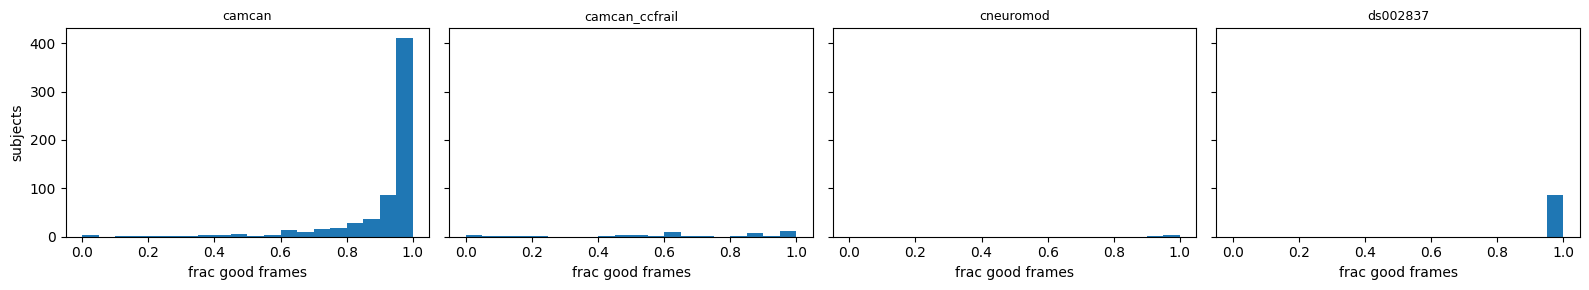

In [13]:
if HAVE_MPL:
    fig, ax = plt.subplots(1, len(act), figsize=(4 * len(act), 3), sharey=True)
    for a, (cohort, df) in zip(np.atleast_1d(ax), act.items()):
        a.hist(df.groupby("sub")["good_frame"].mean(), bins=20, range=(0, 1))
        a.set_title(cohort, fontsize=9)
        a.set_xlabel("frac good frames")
    np.atleast_1d(ax)[0].set_ylabel("subjects")
    fig.tight_layout()

## 4. The fine atlas, one subject at a time

`harvardoxford` is 111 parcels. A whole cohort with parcels is a real read, so
price it from the parquet footers before deciding, and take metadata-only or
one subject when you do not need it.

In [14]:
fine_ds, _ = nb.dataset("activation", ATLAS_FINE)
target = COHORTS[0]
filt = pads.field("cohort") == target

gb_all, n_frag = nb.estimate_gb(fine_ds, filter=filt)
gb_meta, _ = nb.estimate_gb(fine_ds, columns=nb.ACTIVATION_META_COLUMNS, filter=filt)
print(f"{target} @ {ATLAS_FINE}: {n_frag} shard(s)")
print(f"  all columns      {gb_all * 1000:9.2f} MB uncompressed")
print(f"  metadata only    {gb_meta * 1000:9.2f} MB   <- the first-look read")
print(f"  parcel columns   {len(nb.parcel_columns(fine_ds))}")

camcan @ harvardoxford: 648 shard(s)
  all columns          77.56 MB uncompressed
  metadata only         2.32 MB   <- the first-look read
  parcel columns   111


In [15]:
# Metadata only: no parcel data is read off disk at all.
meta_fine = nb.load_activation(ATLAS_FINE, cohort=target)
print(len(meta_fine), "rows", round(nb.mem_mb(meta_fine), 1), "MB")

# One subject, with parcels.
sub0 = sorted(meta_fine["sub"].unique())[0]
one = nb.load_activation(ATLAS_FINE, cohort=target, sub=sub0, with_parcels=True)
print(f"sub-{sub0}: {one.shape}  {round(nb.mem_mb(one), 1)} MB")
one.iloc[:3, :8]

125064 rows 55.0 MB
sub-CC110033: (193, 124)  0.2 MB


,t,time_s,stimulus_time_s,good_frame,run_idx,ses,run,acq
0,0,0.00,0.00,True,0,None,None,None
1,1,2.47,2.47,True,0,None,None,None
2,2,4.94,4.94,True,0,None,None,None


## 5. Who these subjects are

Three files, three owners, joined on `sub` (and `task`, where the row is per
run):

| file | owner | carries |
|---|---|---|
| `config/*_participants.csv` | human | curation — `excluded`, `exclusion_reason` |
| `outputs/meta/cohorts/cohort=*/participants_qc.csv` | pipeline | measurement — motion, coverage, scrubbing |
| `config/phenotype/*_phenotype.csv` | human | **age, sex, clinical scores** |
| `outputs/meta/.../participants_scores.csv` | script | Cam-CAN's behavioural battery (`camcan` only) |

The fourth is Cam-CAN's own `cc700-scored/` battery — ten tests, one column
block each — consolidated by
`preprocessing/camcan/03_build_participants_scores.py`. It exists for `camcan`
and not for `camcan_ccfrail`: none of ccfrail's 55 subjects took it.

The third does not exist yet. Age and sex are in none of the files this
pipeline reads or writes — they come from each dataset's own source table
(OpenNeuro's `participants.tsv`, the Cam-CAN archive's scored files) and are
imported once by `tools/make_phenotype.py`. `config/phenotype/README.md` says
where each cohort's lives. Until then `subject_table` says so and carries on,
with `has_pheno=False` marking every row.

**No threshold is applied anywhere below.** `mean_fd` is a measurement;
`mean_fd > 0.5 → exclude` is a claim, and it belongs with the model that rests
on it, so a sensitivity analysis can move it without re-running any of this.

In [16]:
subjects = {c: nb.subject_table(c) for c in COHORTS}

pd.DataFrame([{
    "cohort": c,
    "rows": len(t),
    "subs": t["sub"].nunique(),
    "excluded": int(t["excluded"].sum()),
    "has_qc": int(t["mean_fd"].notna().sum()) if "mean_fd" in t else 0,
    "has_phenotype": int(t["has_pheno"].sum()),
    "has_scores": int(t["has_scores"].sum()),
    "age": "yes" if "age" in t.columns else "-",
    "sex": "yes" if "sex" in t.columns else "-",
} for c, t in subjects.items()])

/project/6008063/tamires/DecomposingfMRI/notebooks/nbtools.py:558: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["has_scores"] = out["has_scores"].fillna(False)


no phenotype for cohort='camcan' at config/phenotype/camcan_phenotype.csv
  Build it: python tools/make_phenotype.py --help (sources listed in config/phenotype/README.md)
no phenotype for cohort='camcan_ccfrail' at config/phenotype/camcan_ccfrail_phenotype.csv
  Build it: python tools/make_phenotype.py --help (sources listed in config/phenotype/README.md)
no phenotype for cohort='cneuromod' at config/phenotype/cneuromod_phenotype.csv
  Build it: python tools/make_phenotype.py --help (sources listed in config/phenotype/README.md)
no phenotype for cohort='ds002837' at config/phenotype/ds002837_phenotype.csv
  Build it: python tools/make_phenotype.py --help (sources listed in config/phenotype/README.md)


,cohort,rows,subs,excluded,has_qc,has_phenotype,has_scores,age,sex
0,camcan,648,648,0,648,0,646,-,-
1,camcan_ccfrail,55,55,1,54,0,0,-,-
2,cneuromod,288,6,48,240,0,0,-,-
3,ds002837,86,86,0,86,0,0,-,-


In [17]:
# Motion, per cohort, as measured. ccfrail is the frailty cohort and its
# censoring is heavy -- which is itself a confound, since it removes the most
# data from exactly the participants the study is about.
qc_cols = ["mean_fd", "median_fd", "max_fd", "frac_fd_gt_0p2", "frac_fd_gt_0p5"]
motion = pd.concat([t.assign(cohort=c) for c, t in subjects.items()], ignore_index=True)
present = [c for c in qc_cols if c in motion.columns]
motion.groupby("cohort")[present].describe().T if present else "no QC joined"

cohort                    camcan  camcan_ccfrail   cneuromod   ds002837
mean_fd        count  648.000000       54.000000  240.000000  86.000000
               mean     0.164149        0.346610    0.117432   0.115058
               std      0.125273        0.172119    0.057834   0.037998
               min      0.033003        0.141356    0.014982   0.060304
               25%      0.084975        0.240452    0.071820   0.087908
               50%      0.127425        0.323862    0.119606   0.106714
               75%      0.193167        0.398817    0.154783   0.128909
               max      1.153399        1.158840    0.274618   0.219914
median_fd      count  648.000000       54.000000  240.000000  86.000000
               mean     0.130771        0.315519    0.100753   0.100140
               std      0.095730        0.156489    0.051758   0.030485
               min      0.030616        0.113824    0.011432   0.055512
               25%      0.071298        0.225910    0.056007   0.075711
               50%      0.102897        0.279813    0.099696   0.096728
               75%      0.159711        0.359972    0.138703   0.115077
               max      1.001581        0.914755    0.230250   0.221160
max_fd         count  648.000000       54.000000  240.000000  86.000000
               mean     1.088970        1.832524    0.812345   1.390113
               std      1.364306        1.409405    0.628371   0.915748
               min      0.075490        0.514591    0.048064   0.330390
               25%      0.381643        0.875186    0.401517   0.857512
               50%      0.658952        1.519635    0.645678   1.196879
               75%      1.251075        2.081418    1.018620   1.504893
               max     15.589697        8.458849    3.579869   5.470793
frac_fd_gt_0p2 count  648.000000       54.000000  240.000000  86.000000
               mean     0.215374        0.652838    0.153897   0.099258
               std      0.240685        0.194229    0.151283   0.114053
               min      0.000000        0.166667    0.000000   0.000978
               25%      0.031250        0.563794    0.020974   0.020157
               50%      0.111979        0.660880    0.106360   0.062637
               75%      0.325521        0.781829    0.238577   0.126320
               max      1.000000        0.988426    0.575163   0.574412
frac_fd_gt_0p5 count  648.000000       54.000000  240.000000  86.000000
               mean     0.044544        0.189911    0.011206   0.009831
               std      0.097529        0.200540    0.017950   0.017957
               min      0.000000        0.002315    0.000000   0.000000
               25%      0.000000        0.035301    0.000000   0.000537
               50%      0.010417        0.155093    0.004206   0.002985
               75%      0.041667        0.258102    0.013297   0.009489
               max      0.968750        0.870370    0.112033   0.097466

In [18]:
# The analysis-ready subject frame: one row per (cohort, task, sub), curation +
# QC + phenotype + what stage 2 actually produced for them.
per_sub = pd.concat([
    df.groupby(["cohort", "task", "sub"])
      .agg(n_tr=("t", "size"), frac_good=("good_frame", "mean"))
      .reset_index()
    for df in act.values()
], ignore_index=True)

analysis = pd.concat(subjects.values(), ignore_index=True).merge(
    per_sub, on=["cohort", "task", "sub"], how="outer", indicator=True)
print(analysis["_merge"].value_counts().rename("join outcome"))
analysis.head()

_merge
both          1028
left_only       49
right_only       0
Name: join outcome, dtype: int64


,participant_id,sub,cohort,task,excluded,exclusion_reason,mean_fd,median_fd,max_fd,frac_fd_gt_0p2,frac_fd_gt_0p5,n_fd_frames,n_motion_runs,best_lag_tr,peak_isc,n_isc_subjects,frac_stimulus_covered,stimulus_duration_s,n_tr_total,frac_good_frames,n_tr_good,frac_parcels_empty,n_parcels,n_parcels_empty,qc_atlas,fd_source,fd_columns,qc_note,n_tests_with_data,CardioMeasures_RAinit,...,Synsem_reITRTyes_semunamb,Synsem_reITRTno_semunamb,Synsem_pValid_semunamb,Synsem_pTimeout_semunamb,Synsem_pAnticipation_semunamb,Synsem_pYes_semunacc,Synsem_pNo_semunacc,Synsem_RTvalid_semunacc,Synsem_RTyes_semunacc,Synsem_RTno_semunacc,Synsem_reITRTvalid_semunacc,Synsem_reITRTyes_semunacc,Synsem_reITRTno_semunacc,Synsem_pValid_semunacc,Synsem_pTimeout_semunacc,Synsem_pAnticipation_semunacc,TOT_sum_KC,TOT_sum_KI,TOT_sum_TO,TOT_sum_DK,TOT_sum_SE,TOT_sum_NU,TOT_ToT_ratio,TOT_ErrorMessages,has_scores,has_pheno,end_movie,n_tr,frac_good,_merge
0,sub-CC110033,CC110033,camcan,Movie,False,NaN,0.084087,0.073315,0.305603,0.031250,0.000000,192.0,1.0,0.0,0.449750,648.0,1.0,476.70999,193.0,1.000000,193.0,0.0,111.0,0.0,harvardoxford,sub-CC110033_task-Movie_desc-confounds_timeser...,"'framewise_displacement', as computed upstream",NaN,8.0,NaN,...,1576.2820,1930.023,1.0,0.0,0.0,0.04762,0.95238,1582.286,2280.000,1547.400,1457.810,2280.0000,1431.991,1.00000,0.00000,0.0,12.0,2.0,7.0,29.0,0.0,0.0,0.36842,NaN,True,False,NaN,193.0,1.000000,both
1,sub-CC110037,CC110037,camcan,Movie,False,NaN,0.367336,0.096163,5.462255,0.260417,0.130208,192.0,1.0,0.0,0.551731,648.0,1.0,476.70999,193.0,0.777202,150.0,0.0,111.0,0.0,harvardoxford,sub-CC110037_task-Movie_desc-confounds_timeser...,"'framewise_displacement', as computed upstream",NaN,7.0,NaN,...,934.7901,2073.000,1.0,0.0,0.0,0.57895,0.42105,2172.632,2303.364,1992.875,2006.421,2166.3420,1821.530,0.90476,0.09524,0.0,34.0,3.0,5.0,7.0,0.0,1.0,0.12821,NaN,True,False,NaN,193.0,0.777202,both
2,sub-CC110045,CC110045,camcan,Movie,False,NaN,0.052359,0.046730,0.427705,0.010417,0.000000,192.0,1.0,0.0,0.594554,648.0,1.0,476.70999,193.0,1.000000,193.0,0.0,111.0,0.0,harvardoxford,sub-CC110045_task-Movie_desc-confounds_timeser...,"'framewise_displacement', as computed upstream",NaN,9.0,NaN,...,1319.5360,2802.000,1.0,0.0,0.0,0.15000,0.85000,2194.850,3180.667,2020.882,1848.755,3115.9810,1724.958,0.95238,0.04762,0.0,18.0,5.0,9.0,18.0,0.0,0.0,0.33333,NaN,True,False,NaN,193.0,1.000000,both
3,sub-CC110056,CC110056,camcan,Movie,False,NaN,0.670139,0.256170,10.969075,0.588542,0.338542,192.0,1.0,0.0,0.379138,648.0,1.0,476.70999,193.0,0.476684,92.0,0.0,111.0,0.0,harvardoxford,sub-CC110056_task-Movie_desc-confounds_timeser...,"'framewise_displacement', as computed upstream",NaN,8.0,NaN,...,1061.2970,3124.000,1.0,0.0,0.0,0.09524,0.90476,1392.429,1729.000,1357.000,1312.311,1710.2610,1280.937,1.00000,0.00000,0.0,34.0,3.0,10.0,3.0,0.0,0.0,0.22727,NaN,True,False,NaN,193.0,0.476684,both
4,sub-CC110069,CC110069,camcan,Movie,False,NaN,0.091389,0.049462,1.029831,0.083333,0.026042,192.0,1.0,1.0,0.400524,648.0,1.0,476.70999,193.0,0.932642,180.0,0.0,111.0,0.0,harvardoxford,sub-CC110069_task-Movie_desc-confounds_timeser...,"'framewise_displacement', as computed upstream",NaN,8.0,NaN,...,846.2338,1325.000,1.0,0.0,0.0,0.23810,0.76190,1078.667,976.600,1110.562,1026.999,926.5033,1063.032,1.00000,0.00000,0.0,4.0,7.0,0.0,38.0,1.0,0.0,0.00000,NaN,True,False,NaN,193.0,0.932642,both


## Where this stops

Loaded, checked, joined. What is deliberately not here: no exclusion applied,
no group contrast, no model. Those need the phenotype, and the healthy-vs-frail
contrast in particular needs the acquisition confound handled — `camcan` and
`camcan_ccfrail` differ in TR (2.47 vs 1.12 s) and echoes (5 vs 1), which moves
edge noise in the same direction as the group effect. Stage 3 is where that
becomes measurable; see `02_dfc.ipynb`.

Memory, if you widen any of this:

* keep one dataset object per atlas — schemas differ across them (111 / 14 / 7);
* filter on partition keys (`cohort`, `task`, `sub`) so whole directories are
  pruned before any file opens;
* project columns — `with_parcels=False` reads no parcel data at all;
* price a read with `nb.estimate_gb(...)` before running it;
* anything needing a full-cohort pass over `harvardoxford` belongs in a batch
  job that writes a summary table, not in this notebook.